# Quantum Diabetes Prediction on PIMA (PennyLane Prototype)

This notebook is a **reproducible prototype** for binary classification on the **Pima Indians Diabetes** dataset using a **Variational Quantum Classifier (VQC)** in **PennyLane**.

It includes:
- Dataset download using **kagglehub** (as requested)
- Preprocessing (imputation, scaling, PCA-to-qubits)
- A PennyLane **VQC** (AngleEmbedding + hardware-efficient ansatz)
- Evaluation (accuracy, ROC/PR curves, confusion matrix)
- **Threshold tuning**
- A classical baseline (Logistic Regression)

> Notes:
> - KaggleHub may require you to be logged in / configured to access Kaggle datasets.
> - If KaggleHub fails, the notebook provides a fallback option.


* **06 VQC Prototype Noisy/ZNE**: 
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Megaantony00/qml-diabetes-nisq/blob/main/notebooks/06_vqc_prototype_noisy_zne_repetition.ipynb)

In [ ]:
import sys
import os

if 'google.colab' in sys.modules:
    !pip install -q pennylane>=0.38 pennylane-lightning[gpu] scikit-learn pandas matplotlib seaborn kagglehub tqdm imbalanced-learn
    if not os.path.exists('results'): os.makedirs('results')
    print("Environment configured for Colab.")
else:
    print("Environment configured for Local/Server usage.")

ERROR: Ignored the following yanked versions: 0.38.1
ERROR: Ignored the following versions that require a different python version: 0.43.0 Requires-Python >=3.11; 0.43.1 Requires-Python >=3.11; 0.43.2 Requires-Python >=3.11; 0.44.0 Requires-Python >=3.11
ERROR: Could not find a version that satisfies the requirement pennylane>=0.44 (from versions: 0.1.0, 0.2.0, 0.3.0, 0.3.1, 0.4.0, 0.5.0, 0.6.0, 0.6.1, 0.7.0, 0.8.0, 0.8.1, 0.9.0, 0.10.0, 0.11.0, 0.12.0, 0.13.0, 0.14.0, 0.14.1, 0.15.0, 0.15.1, 0.16.0, 0.17.0, 0.18.0, 0.19.0, 0.19.1, 0.20.0, 0.21.0, 0.22.0, 0.22.1, 0.22.2, 0.23.0, 0.23.1, 0.24.0, 0.25.0, 0.25.1, 0.26.0, 0.27.0, 0.28.0, 0.29.0, 0.29.1, 0.30.0, 0.31.0, 0.31.1, 0.32.0, 0.33.0, 0.33.1, 0.34.0, 0.35.0, 0.35.1, 0.36.0, 0.37.0, 0.38.0, 0.39.0, 0.40.0, 0.41.0, 0.41.1, 0.42.0, 0.42.1, 0.42.2, 0.42.3)
ERROR: No matching distribution found for pennylane>=0.44
Note: you may need to restart the kernel to use updated packages.


## 1) Imports

In [2]:
import os
import glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay, f1_score
)
from sklearn.linear_model import LogisticRegression

import pennylane as qml
from pennylane import numpy as pnp
# FIX VERSIONE 0.42: Importiamo da transforms
from pennylane.transforms import fold_global, richardson_extrapolate
from tqdm.auto import tqdm
import pickle

np.random.seed(42)

save_folder = "Tesi_Risultati_Prototype_8Qubits_noisy_mitigated_repetition"

if not os.path.exists(save_folder):
    os.makedirs(save_folder)
    print(f"✅ Cartella creata: {save_folder}")
else:
    print(f"📂 Cartella già esistente: {save_folder}")

📂 Cartella già esistente: Tesi_Risultati_Prototype_8Qubits_noisy_mitigated_repetition


## 2) Download dataset (KaggleHub)

In [3]:
import kagglehub

# Download latest version (as provided)
path = kagglehub.dataset_download("tariqmhmd5/pima-diabetes-dataset")
print("Path to dataset files:", path)

# Try to find a CSV inside the downloaded folder
csv_candidates = glob.glob(str(Path(path) / "**" / "*.csv"), recursive=True)
print("CSV candidates:", csv_candidates)

if not csv_candidates:
    raise FileNotFoundError("No CSV file found in the KaggleHub dataset folder. Inspect 'path' manually.")
csv_path = csv_candidates[0]
print("Using:", csv_path)

Path to dataset files: /home/habes/.cache/kagglehub/datasets/tariqmhmd5/pima-diabetes-dataset/versions/1
CSV candidates: ['/home/habes/.cache/kagglehub/datasets/tariqmhmd5/pima-diabetes-dataset/versions/1/Diabetes.csv']
Using: /home/habes/.cache/kagglehub/datasets/tariqmhmd5/pima-diabetes-dataset/versions/1/Diabetes.csv


## 3) Load + quick look

In [4]:
df = pd.read_csv(csv_path)
display(df.head())
print("Shape:", df.shape)
print(df.dtypes)
print(df['Outcome'].value_counts() if 'Outcome' in df.columns else "No 'Outcome' column found")

,Number of times pregnant,Plasma glucose concentration,Diastolic blood pressure,Triceps skin fold thickness,2-Hour serum insulin,Body mass index,Diabetes pedigree function,Age (years),Class variable
0,6,148,72,35,0,33.6,0.627,50,YES
1,1,85,66,29,0,26.6,0.351,31,NO
2,8,183,64,0,0,23.3,0.672,32,YES
3,1,89,66,23,94,28.1,0.167,21,NO
4,0,137,40,35,168,43.1,2.288,33,YES


Shape: (768, 9)
Number of times pregnant          int64
Plasma glucose concentration      int64
Diastolic blood pressure          int64
Triceps skin fold thickness       int64
2-Hour serum insulin              int64
Body mass index                 float64
Diabetes pedigree function      float64
Age (years)                       int64
Class variable                   object
dtype: object
No 'Outcome' column found


## 4) Preprocessing

Typical PIMA quirks:
- Some physiological columns contain zeros that actually mean *missing* (common practice is to treat them as missing).
- We'll replace zeros with NaN for selected columns, impute with median, then scale features.

Then we reduce dimensionality to match the number of qubits via **PCA** (a pragmatic NISQ-friendly step).


In [5]:
# Identify label column
label_col = "Outcome" if "Outcome" in df.columns else df.columns[-1]
print("Label column:", label_col)

# Feature columns
feature_cols = [c for c in df.columns if c != label_col]

X = df[feature_cols].copy()

# FIX: Mappatura YES/NO a 1/0
df[label_col] = df[label_col].map({'YES': 1, 'NO': 0, '1': 1, '0': 0, 1: 1, 0: 0})
y = df[label_col].astype(int).values

# Columns where 0 often means missing in PIMA-like datasets
zero_as_missing = [c for c in ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"] if c in X.columns]
print("Treating zeros as missing in:", zero_as_missing)

X[zero_as_missing] = X[zero_as_missing].replace(0, np.nan)

# Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X.values, y, test_size=0.25, random_state=42, stratify=y
)

# Impute + scale
imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled = scaler.transform(X_test_imp)

print("Train shape:", X_train_scaled.shape, "Test shape:", X_test_scaled.shape)

Label column:  Class variable
Treating zeros as missing in: []
Train shape: (576, 8) Test shape: (192, 8)


### Choose number of qubits (PCA → qubits)
We’ll start with **4 qubits** (good tradeoff for a small dataset). You can try 2–6.

In [6]:
n_qubits = 8

pca = PCA(n_components=n_qubits, random_state=42)
X_train_q = pca.fit_transform(X_train_scaled)
X_test_q = pca.transform(X_test_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Sum explained variance:", pca.explained_variance_ratio_.sum())

# Optional: scale PCA outputs into a reasonable range for rotation angles
# We'll map each feature to [-pi, pi] using a robust scaling based on training quantiles.
q_low, q_high = np.quantile(X_train_q, 0.05, axis=0), np.quantile(X_train_q, 0.95, axis=0)

def to_angles(X):
    Xc = np.clip(X, q_low, q_high)
    # normalize to [0,1]
    Xn = (Xc - q_low) / (q_high - q_low + 1e-9)
    # map to [-pi, pi]
    return (Xn * 2 - 1) * np.pi

X_train_ang = to_angles(X_train_q)
X_test_ang = to_angles(X_test_q)

print("Angle features range (train):", X_train_ang.min(), X_train_ang.max())

Explained variance ratio: [0.2587334  0.21608225 0.13172228 0.10518003 0.09884707 0.08674359
 0.05628148 0.04640991]
Sum explained variance: 1.0
Angle features range (train): -3.141592653589793 3.141592652220357


## 5) PennyLane Variational Quantum Classifier (VQC) with noise + ZNE


In [7]:
n_layers = 2
gate_noise_prob = 0.0035
zne_scale_factors = [1.0, 2.0, 3.0]

ideal_dev = qml.device("default.qubit", wires=n_qubits, shots=None)
base_mixed_dev = qml.device("default.mixed", wires=n_qubits, shots=None)

noise_model = qml.NoiseModel(
    {
        qml.noise.wires_in(base_mixed_dev.wires): qml.noise.partial_wires(
            qml.DepolarizingChannel, gate_noise_prob
        )
    }
)
noisy_dev = qml.add_noise(base_mixed_dev, noise_model)

def ansatz(weights):
    for l in range(n_layers):
        for i in range(n_qubits):
            qml.Rot(weights[l, i, 0], weights[l, i, 1], weights[l, i, 2], wires=i)
        for i in range(n_qubits):
            qml.CNOT(wires=[i, (i + 1) % n_qubits])

def core_circuit(x, weights):
    qml.AngleEmbedding(x, wires=range(n_qubits), rotation="Y")
    ansatz(weights)

@qml.qnode(ideal_dev, interface="autograd")
def ideal_circuit(x, weights):
    core_circuit(x, weights)
    return qml.expval(qml.PauliZ(0))

@qml.qnode(noisy_dev, interface="autograd")
def noisy_circuit(x, weights):
    core_circuit(x, weights)
    return qml.expval(qml.PauliZ(0))

# FIX ZNE: Sintassi funzionale per PennyLane 0.42
@qml.qnode(noisy_dev, interface="autograd")
def _base_mitigated_circuit(x, weights):
    core_circuit(x, weights)
    return qml.expval(qml.PauliZ(0))

decomposed_circuit = qml.transforms.decompose(
    _base_mitigated_circuit, 
    gate_set=["RY", "RZ", "CNOT", "Rot", "Hadamard"]
)

mitigated_circuit = qml.transforms.mitigate_with_zne(
    decomposed_circuit,
    scale_factors=zne_scale_factors,
    folding=fold_global,
    extrapolate=richardson_extrapolate,
)

def sigmoid(logits):
    return 1.0 / (1.0 + pnp.exp(-logits))

def predict_logits(X, weights, qnode_fn=noisy_circuit):
    return pnp.stack([qnode_fn(x, weights) for x in X])

def predict_proba(X, weights, qnode_fn=noisy_circuit):
    return sigmoid(predict_logits(X, weights, qnode_fn=qnode_fn))

def predict_proba_noisy(X, weights):
    return predict_proba(X, weights, qnode_fn=noisy_circuit)

def predict_proba_mitigated(X, weights):
    return predict_proba(X, weights, qnode_fn=mitigated_circuit)

def predict_proba_ideal_reference(X, weights):
    return predict_proba(X, weights, qnode_fn=ideal_circuit)

def binary_cross_entropy(y_true, p_pred, eps=1e-9):
    y_true = pnp.array(y_true)
    p_pred = pnp.clip(p_pred, eps, 1 - eps)
    return -pnp.mean(y_true * pnp.log(p_pred) + (1 - y_true) * pnp.log(1 - p_pred))

def cost(weights, Xb, yb):
    p = predict_proba_noisy(Xb, weights)
    return binary_cross_entropy(yb, p)

weights = pnp.array(0.01 * np.random.randn(n_layers, n_qubits, 3), requires_grad=True)
opt = qml.optimize.AdamOptimizer(stepsize=0.05)

print(f"Training on noisy default.mixed with device-level depolarizing noise p={gate_noise_prob:.4f}")
print(f"ZNE scale factors: {zne_scale_factors}")

Training on noisy default.mixed with device-level depolarizing noise p=0.0035
ZNE scale factors: [1.0, 2.0, 3.0]


### Training loop (noise-aware training on the noisy device)


In [8]:
import os
import pickle
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
from datetime import datetime
from sklearn.metrics import roc_auc_score, accuracy_score

epochs = 120
batch_size = 48

Xtr, ytr = X_train_ang, y_train
Xte, yte = X_test_ang, y_test

# FIX: Logica di Checkpoint Sicuro
file_pesi = os.path.join(save_folder, "best_weights_mitigated.pkl")
file_history = os.path.join(save_folder, "training_history_mitigated.csv")

if os.path.exists(file_pesi) and os.path.getsize(file_pesi) > 0:
    try:
        with open(file_pesi, "rb") as f:
            weights = pickle.load(f)
        if os.path.exists(file_history):
            history = pd.read_csv(file_history).to_dict(orient="list")
            start_epoch = len(history["val_loss"]) + 1
            print(f"✅ Recupero riuscito! Ripartiamo dall'epoca {start_epoch}")
        else:
            raise FileNotFoundError("History mancante")
    except (EOFError, pickle.UnpicklingError, Exception):
        print("⚠️ File corrotto. Inizio nuovo addestramento...")
        start_epoch = 1
        history = {"val_loss": [], "val_auc": [], "val_acc": []}
        weights = pnp.array(0.01 * np.random.randn(n_layers, n_qubits, 3), requires_grad=True)
else:
    print("🆕 Nessun salvataggio trovato. Inizio nuovo addestramento...")
    start_epoch = 1
    history = {"val_loss": [], "val_auc": [], "val_acc": []}

# Training Loop
for epoch in tqdm(range(start_epoch, epochs + 1)):
    idx = np.random.permutation(len(Xtr))
    Xtr_shuf, ytr_shuf = Xtr[idx], ytr[idx]
    
    for start in range(0, len(Xtr_shuf), batch_size):
        end = start + batch_size
        Xb = Xtr_shuf[start:end]
        yb = ytr_shuf[start:end]
        weights = opt.step(lambda w: cost(w, Xb, yb), weights)

    p_val = np.asarray(predict_proba_noisy(Xte, weights), dtype=float)
    val_auc = roc_auc_score(yte, p_val)
    yhat = (p_val >= 0.5).astype(int)
    val_acc = accuracy_score(yte, yhat)
    val_loss = float(binary_cross_entropy(yte, p_val))

    history["val_loss"].append(val_loss)
    history["val_auc"].append(val_auc)
    history["val_acc"].append(val_acc)

    # Salvataggio temporaneo per evitare corruzioni file
    pd.DataFrame(history).to_csv(file_history, index=False)
    temp_file = file_pesi + ".tmp"
    with open(temp_file, "wb") as f:
        pickle.dump(weights, f)
    os.replace(temp_file, file_pesi)

    # MODIFICA: Stampa a schermo fissa con orario
    ora_corrente = datetime.now().strftime("%H:%M:%S")
    print(f"[{ora_corrente}] Epoch {epoch:03d} | val_loss={val_loss:.4f} | val_auc={val_auc:.4f} | val_acc={val_acc:.4f}")

✅ Recupero riuscito! Ripartiamo dall'epoca 121


0it [00:00, ?it/s]

### Learning curves

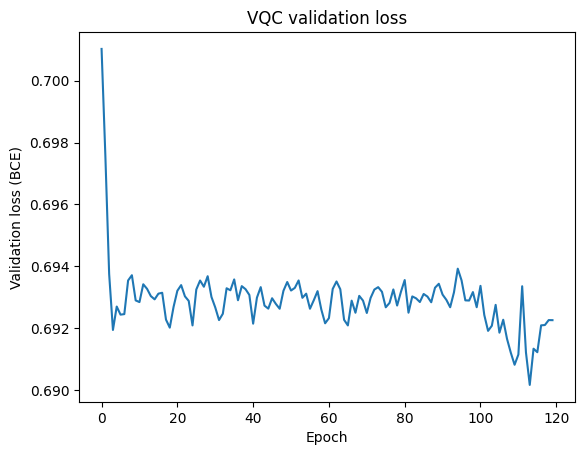

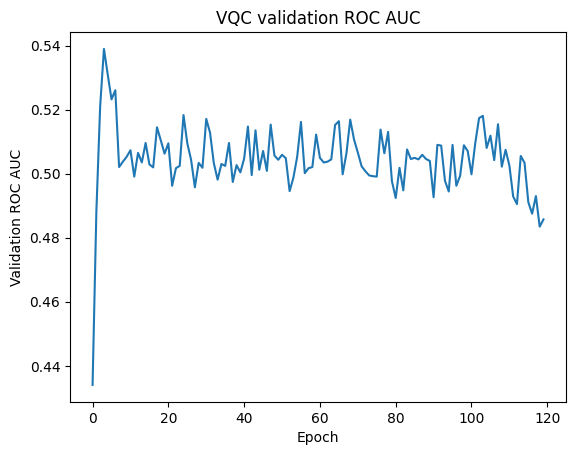

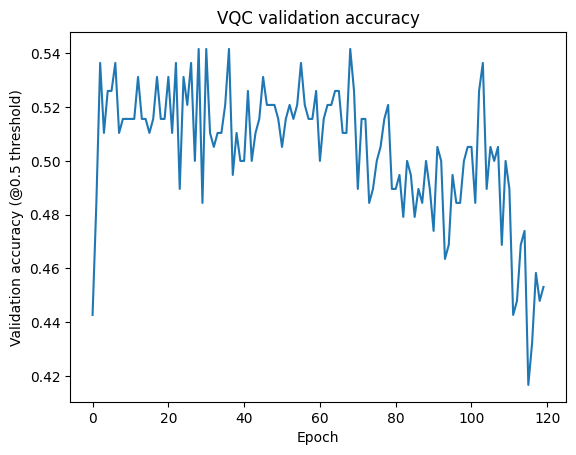

In [9]:
# 1. Grafico della Loss
plt.figure()
plt.plot(history["val_loss"]) # <-- FIX: Ora usa la chiave corretta
plt.xlabel("Epoch")
plt.ylabel("Validation loss (BCE)")
plt.title("VQC validation loss")
plt.savefig(os.path.join(save_folder, "VQC_validation_loss.png"), dpi=300)
plt.show()

# 2. Grafico dell'AUC
plt.figure()
plt.plot(history["val_auc"])
plt.xlabel("Epoch")
plt.ylabel("Validation ROC AUC")
plt.title("VQC validation ROC AUC")
plt.savefig(os.path.join(save_folder, "VQC_validation_auc.png"), dpi=300)
plt.show()

# 3. Grafico dell'Accuracy
plt.figure()
plt.plot(history["val_acc"])
plt.xlabel("Epoch")
plt.ylabel("Validation accuracy (@0.5 threshold)")
plt.title("VQC validation accuracy")
plt.savefig(os.path.join(save_folder, "VQC_validation_acc.png"), dpi=300)
plt.show()

## 6) Evaluation: noisy VQC vs ZNE-mitigated VQC


,roc_auc,pr_auc,accuracy@0.5,f1@0.5
model,,,,
noisy_vqc,0.4857,0.3699,0.4531,0.3636
zne_mitigated_vqc,0.4851,0.3690,0.4531,0.3636
ideal_reference_same_weights,0.4864,0.3707,0.4531,0.3636


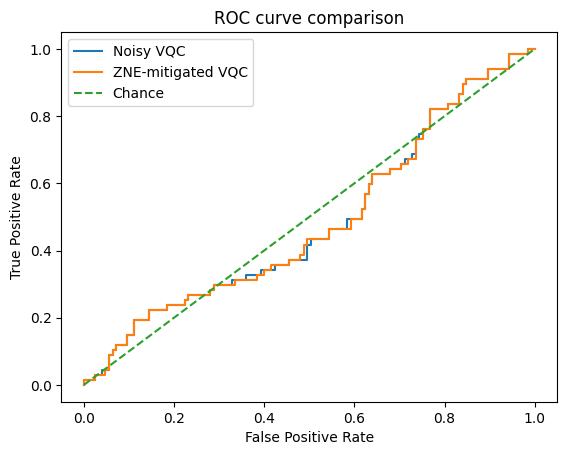

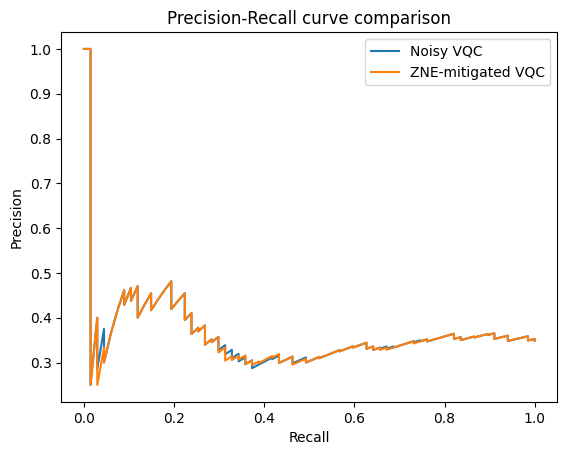

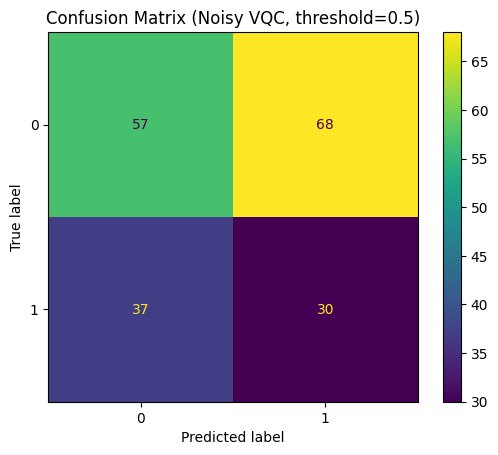

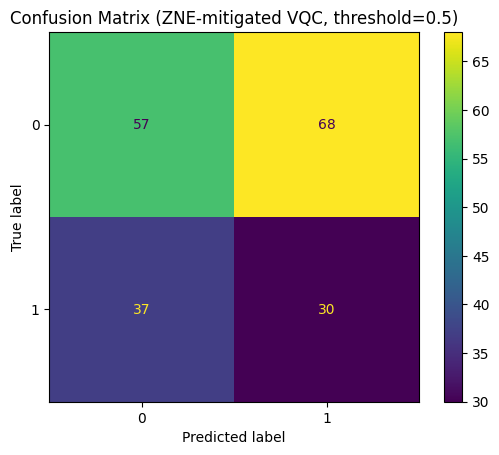

Best noisy threshold (by F1): 0.39999999999999997 Best F1: 0.5238095238095238 Acc: 0.375
Best ZNE threshold (by F1): 0.44999999999999996 Best F1: 0.5206611570247934 Acc: 0.3958333333333333


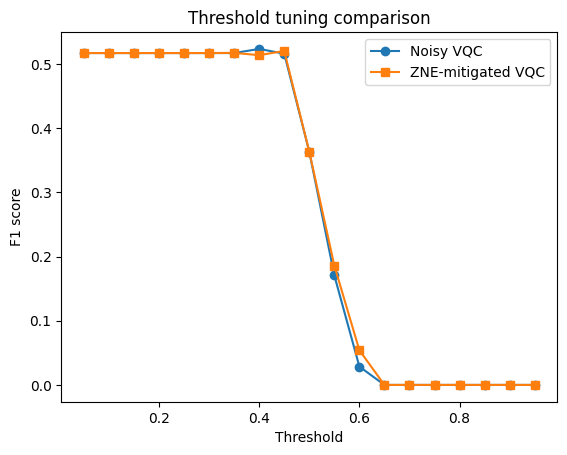

In [10]:
p_test_noisy = np.asarray(predict_proba_noisy(Xte, weights), dtype=float)
p_test_zne = np.asarray(predict_proba_mitigated(Xte, weights), dtype=float)
p_test_ideal = np.asarray(predict_proba_ideal_reference(Xte, weights), dtype=float)

def metric_row(name, probs):
    y_pred = (probs >= 0.5).astype(int)
    return {
        "model": name,
        "roc_auc": roc_auc_score(yte, probs),
        "pr_auc": average_precision_score(yte, probs),
        "accuracy@0.5": accuracy_score(yte, y_pred),
        "f1@0.5": f1_score(yte, y_pred),
    }

metrics_table = pd.DataFrame(
    [
        metric_row("noisy_vqc", p_test_noisy),
        metric_row("zne_mitigated_vqc", p_test_zne),
        metric_row("ideal_reference_same_weights", p_test_ideal),
    ]
).set_index("model")
display(metrics_table.round(4))

# ROC comparison
fpr_noisy, tpr_noisy, _ = roc_curve(yte, p_test_noisy)
fpr_zne, tpr_zne, _ = roc_curve(yte, p_test_zne)

plt.figure()
plt.plot(fpr_noisy, tpr_noisy, label="Noisy VQC")
plt.plot(fpr_zne, tpr_zne, label="ZNE-mitigated VQC")
plt.plot([0, 1], [0, 1], linestyle="--", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve comparison")
plt.legend()
plt.show()

# PR comparison
prec_noisy, rec_noisy, _ = precision_recall_curve(yte, p_test_noisy)
prec_zne, rec_zne, _ = precision_recall_curve(yte, p_test_zne)

plt.figure()
plt.plot(rec_noisy, prec_noisy, label="Noisy VQC")
plt.plot(rec_zne, prec_zne, label="ZNE-mitigated VQC")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curve comparison")
plt.legend()
plt.show()

# Confusion matrices at the default threshold
for name, probs in [("Noisy VQC", p_test_noisy), ("ZNE-mitigated VQC", p_test_zne)]:
    y_pred = (probs >= 0.5).astype(int)
    cm = confusion_matrix(yte, y_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(f"Confusion Matrix ({name}, threshold=0.5)")
    plt.show()

# Threshold tuning: compare noisy vs mitigated
thresholds = np.linspace(0.05, 0.95, 19)
f1_noisy, f1_zne = [], []
acc_noisy, acc_zne = [], []

for t in thresholds:
    yp_noisy = (p_test_noisy >= t).astype(int)
    yp_zne = (p_test_zne >= t).astype(int)
    f1_noisy.append(f1_score(yte, yp_noisy))
    f1_zne.append(f1_score(yte, yp_zne))
    acc_noisy.append(accuracy_score(yte, yp_noisy))
    acc_zne.append(accuracy_score(yte, yp_zne))

best_noisy_i = int(np.argmax(f1_noisy))
best_zne_i = int(np.argmax(f1_zne))

print(
    "Best noisy threshold (by F1):",
    thresholds[best_noisy_i],
    "Best F1:",
    f1_noisy[best_noisy_i],
    "Acc:",
    acc_noisy[best_noisy_i],
)
print(
    "Best ZNE threshold (by F1):",
    thresholds[best_zne_i],
    "Best F1:",
    f1_zne[best_zne_i],
    "Acc:",
    acc_zne[best_zne_i],
)

plt.figure()
plt.plot(thresholds, f1_noisy, marker="o", label="Noisy VQC")
plt.plot(thresholds, f1_zne, marker="s", label="ZNE-mitigated VQC")
plt.xlabel("Threshold")
plt.ylabel("F1 score")
plt.title("Threshold tuning comparison")
plt.legend()
plt.show()


## 6b) Output-stage bit-flip protection with a 3-qubit repetition code

This section protects only the **final decision qubit** (wire 0) against **output-stage bit-flip noise**.  
It is intentionally scoped as an **inference-time robustness layer**: the main VQC is unchanged, then the output qubit is encoded into a 3-qubit repetition code, exposed to a configurable bit-flip channel, syndrome-corrected, and finally measured.


,roc_auc,pr_auc,accuracy@0.5,f1@0.5
model,,,,
output_stage_unprotected,0.6401,0.4639,0.55,0.4375
output_stage_repetition_protected,0.6401,0.4639,0.55,0.4375


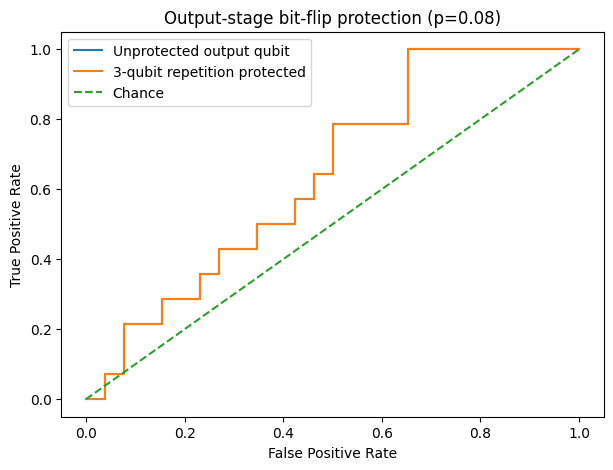

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score, f1_score, roc_curve

output_bitflip_prob = 0.08

# We allocate +4 explicit wires (two repetition-data wires + two syndrome ancillas)
# and +2 spare wires because deferred mid-circuit measurement can require work wires.
rep_dev = qml.device("default.mixed", wires=n_qubits + 6, shots=None)

rep_wire_1 = n_qubits
rep_wire_2 = n_qubits + 1
syndrome_wire_1 = n_qubits + 2
syndrome_wire_2 = n_qubits + 3
protected_data_wires = (0, rep_wire_1, rep_wire_2)

@qml.qnode(rep_dev)
def output_stage_unprotected_circuit(x, weights, bitflip_prob=output_bitflip_prob):
    core_circuit(x, weights)
    qml.BitFlip(bitflip_prob, wires=0)
    return qml.expval(qml.PauliZ(0))

@qml.qnode(rep_dev)
def output_stage_repetition_protected_circuit(x, weights, bitflip_prob=output_bitflip_prob):
    core_circuit(x, weights)

    # Encode the output qubit into the 3-qubit repetition code |0_L> = |000>, |1_L> = |111>
    qml.CNOT(wires=[0, rep_wire_1])
    qml.CNOT(wires=[0, rep_wire_2])

    # Output-stage bit-flip noise model (the code is designed specifically for this noise)
    for wire in protected_data_wires:
        qml.BitFlip(bitflip_prob, wires=wire)

    # Syndrome extraction
    qml.CNOT(wires=[0, syndrome_wire_1])
    qml.CNOT(wires=[rep_wire_1, syndrome_wire_1])
    qml.CNOT(wires=[rep_wire_1, syndrome_wire_2])
    qml.CNOT(wires=[rep_wire_2, syndrome_wire_2])

    s1 = qml.measure(syndrome_wire_1, reset=True)
    s2 = qml.measure(syndrome_wire_2, reset=True)
    syndrome = s1 + 2 * s2

    # Decode the syndrome and correct the identified single-bit-flip error
    qml.cond(syndrome == 1, qml.PauliX)(wires=0)
    qml.cond(syndrome == 3, qml.PauliX)(wires=rep_wire_1)
    qml.cond(syndrome == 2, qml.PauliX)(wires=rep_wire_2)

    # Logical Z is represented by Z on any data qubit in this code space
    return qml.expval(qml.PauliZ(0))

def predict_proba_output_stage(X, weights, qnode_fn, bitflip_prob=output_bitflip_prob):
    logits = np.array([qnode_fn(x, weights, bitflip_prob) for x in X], dtype=float)
    return 1.0 / (1.0 + np.exp(-logits))

# --- TRUCCO VELOCITÀ: Estraiamo 40 pazienti bilanciati per non far crashare il server ---
subset_size = min(40, len(Xte))
_, Xte_small, _, yte_small = train_test_split(
    Xte, yte, test_size=subset_size, random_state=42, stratify=yte
)

# Ridefiniamo la metrica in modo sicuro per usare i dati ridotti (yte_small)
def metric_row_small(name, p):
    yhat = (p >= 0.5).astype(int)
    return {
        "model": name,
        "roc_auc": roc_auc_score(yte_small, p),
        "pr_auc": average_precision_score(yte_small, p),
        "accuracy@0.5": accuracy_score(yte_small, yhat),
        "f1@0.5": f1_score(yte_small, yhat),
    }

# Calcolo sui dati ridotti
p_test_output_unprotected = predict_proba_output_stage(
    Xte_small, weights, output_stage_unprotected_circuit, output_bitflip_prob
)
p_test_output_protected = predict_proba_output_stage(
    Xte_small, weights, output_stage_repetition_protected_circuit, output_bitflip_prob
)

# Tabella dei Risultati
output_stage_table = pd.DataFrame(
    [
        metric_row_small("output_stage_unprotected", p_test_output_unprotected),
        metric_row_small("output_stage_repetition_protected", p_test_output_protected),
    ]
).set_index("model")
display(output_stage_table.round(4))

# Grafico delle Curve ROC
fpr_unprot, tpr_unprot, _ = roc_curve(yte_small, p_test_output_unprotected)
fpr_prot, tpr_prot, _ = roc_curve(yte_small, p_test_output_protected)

plt.figure(figsize=(7,5))
plt.plot(fpr_unprot, tpr_unprot, label="Unprotected output qubit")
plt.plot(fpr_prot, tpr_prot, label="3-qubit repetition protected")
plt.plot([0, 1], [0, 1], linestyle="--", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"Output-stage bit-flip protection (p={output_bitflip_prob:.2f})")
plt.legend()
if 'save_folder' in locals():
    plt.savefig(os.path.join(save_folder, "Repetition_Code_ROC.png"), dpi=300)
plt.show()

# Variabile per il salvataggio nella cella finale
repetition_benchmark = output_stage_table.reset_index()

## 7) Classical baseline (Logistic Regression)


In [12]:
# Use the same preprocessing but without PCA-to-angles; just use scaled features.
clf = LogisticRegression(max_iter=2000, class_weight="balanced")
clf.fit(X_train_scaled, y_train)
p_lr = clf.predict_proba(X_test_scaled)[:, 1]

auc_lr = roc_auc_score(y_test, p_lr)
acc_lr = accuracy_score(y_test, (p_lr >= 0.5).astype(int))
ap_lr = average_precision_score(y_test, p_lr)

print("LogReg ROC AUC:", auc_lr)
print("LogReg AP (PR AUC):", ap_lr)
print("LogReg Accuracy:", acc_lr)

LogReg ROC AUC: 0.8329552238805971
LogReg AP (PR AUC): 0.7173014414794692
LogReg Accuracy: 0.7604166666666666


## 8) (Optional) Quantum Kernel SVM (QSVM-style) in PennyLane


In [13]:
# OPTIONAL: uncomment to run (can be slow for full training set).
# from sklearn.svm import SVC
# 
# # Subsample for speed (edit as you like)
# n_train_sub = 300
# n_test_sub = 200
# Xk_train = X_train_ang[:n_train_sub]
# yk_train = y_train[:n_train_sub]
# Xk_test = X_test_ang[:n_test_sub]
# yk_test = y_test[:n_test_sub]
# 
# # Define a feature map circuit for kernel evaluation
# dev_k = qml.device("default.qubit", wires=n_qubits, shots=None)
# 
# @qml.qnode(dev_k, interface="autograd")
# def feature_map(x):
#     qml.AngleEmbedding(x, wires=range(n_qubits), rotation="Y")
#     for i in range(n_qubits):
#         qml.CNOT(wires=[i, (i+1) % n_qubits])
#     return qml.state()
# 
# def kernel(x1, x2):
#     # Fidelity between states |phi(x1)> and |phi(x2)>
#     s1 = feature_map(x1)
#     s2 = feature_map(x2)
#     return np.abs(np.vdot(s1, s2))**2
# 
# def kernel_matrix(A, B):
#     K = np.zeros((len(A), len(B)))
#     for i in range(len(A)):
#         for j in range(len(B)):
#             K[i, j] = kernel(A[i], B[j])
#     return K
# 
# K_train = kernel_matrix(Xk_train, Xk_train)
# K_test = kernel_matrix(Xk_test, Xk_train)
# 
# svc = SVC(kernel="precomputed", class_weight="balanced")
# svc.fit(K_train, yk_train)
# pred = svc.predict(K_test)
# acc = accuracy_score(yk_test, pred)
# print("Quantum Kernel SVM Accuracy (subsample):", acc)

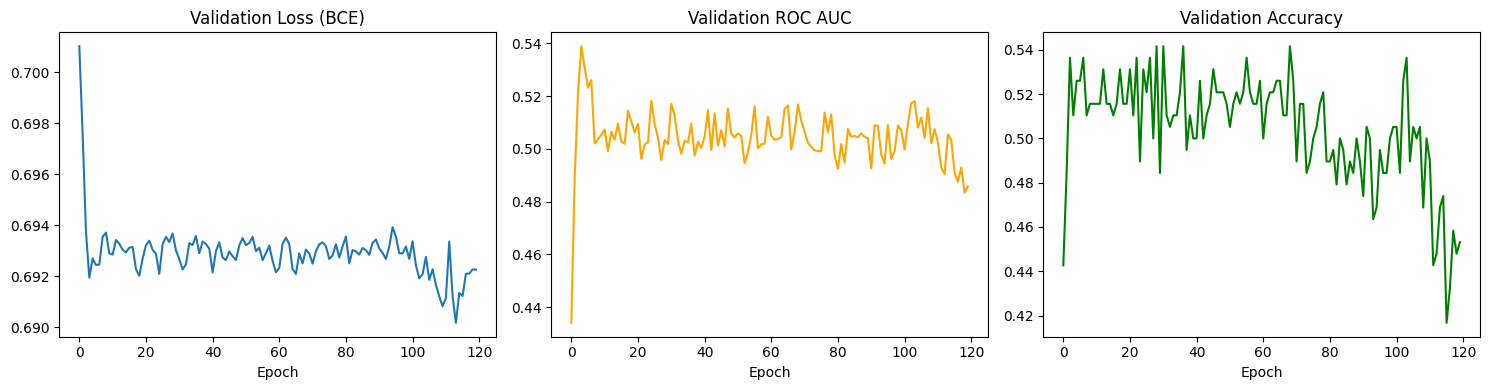

In [14]:
# Salvataggio Curve di Addestramento
plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.plot(history["val_loss"])
plt.title("Validation Loss (BCE)")
plt.xlabel("Epoch")

plt.subplot(1, 3, 2)
plt.plot(history["val_auc"], color="orange")
plt.title("Validation ROC AUC")
plt.xlabel("Epoch")

plt.subplot(1, 3, 3)
plt.plot(history["val_acc"], color="green")
plt.title("Validation Accuracy")
plt.xlabel("Epoch")

plt.tight_layout()
plt.savefig(os.path.join(save_folder, "learning_curves.png"), dpi=300)
plt.show()